# Pilot Study: Clarifying Questions as Signals of Internal Uncertainty

This notebook implements a three-part pilot study to test whether clarifying questions generated by an LLM can help distinguish between two kinds of internal uncertainty:

- **Epistemic uncertainty**: the model has a knowledge gap.
- **Aleatoric uncertainty**: multiple valid answers exist, or the query is underspecified without more user context.

The workflow is organised into clearly separated phases:

1. **Phase 1**: Generate one clarifying question per prompt and manually classify each question.
2. **Phase 2**: Generate repeated clarifying questions to quantify response variation.
3. **Phase 3**: Merge the manual labels with the variation scores and test the core hypothesis statistically.


## Requirements

This notebook uses the following Python packages:

- `pandas`
- `numpy`
- `matplotlib`
- `seaborn`
- `scipy`
- `bert-score`
- `google-generativeai`
- `ipython`

Example installation command:

```bash
pip install pandas numpy matplotlib seaborn scipy bert-score google-generativeai ipython
```

In [1]:
from __future__ import annotations

import itertools
import json
import math
import os
import random
import re
import time
from pathlib import Path
from typing import Iterable

import google.generativeai as genai
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from bert_score import score as bertscore_score
from IPython.display import Markdown, display
from scipy.stats import mannwhitneyu, pointbiserialr

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs"
FIGURE_DIR = ROOT / "figures"
PROMPT_TEMPLATE_PATH = ROOT / "gemini_prompt_template.txt"
PROMPTS_JSON_PATH = ROOT / "study_prompts.json"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
    "figure.dpi": 120,
})

PALETTE = {
    "epistemic": "#1f77b4",
    "aleatoric": "#ff7f0e",
    True: "#2ca02c",
    False: "#d62728",
    "Agreement": "#2ca02c",
    "Disagreement": "#d62728",
}

GENERATED_CQS_PATH = OUTPUT_DIR / "generated_cqs.csv"
LABELLED_CQS_PATH = OUTPUT_DIR / "labelled_cqs.csv"
VARIATION_RUNS_PATH = OUTPUT_DIR / "variation_runs.csv"
VARIATION_SCORES_PATH = OUTPUT_DIR / "variation_scores.csv"

# Using Google's Generative AI API with a model that is currently reachable and stable in this environment.
GEMINI_MODEL = "gemma-3-4b-it"
PHASE1_GENERATION_CONFIG = {
    "temperature": 0.0,
    "top_p": 0.9,
    "max_output_tokens": 512,
}
PHASE2_GENERATION_CONFIG = {
    "temperature": 2.0,
    "top_p": 1.0,
    "max_output_tokens": 512,
}
NO_CLARIFICATION_TOKEN = "NO_CLARIFICATION_NEEDED"


def save_and_show(fig: plt.Figure, filename: str) -> None:
    """Save a figure to disk and display it inline."""
    output_path = FIGURE_DIR / filename
    fig.tight_layout()
    fig.savefig(output_path, bbox_inches="tight")
    plt.show()


def clean_text(text: str) -> str:
    if text is None:
        return ""
    return " ".join(str(text).strip().split())


def word_count(text: str) -> int:
    return len(clean_text(text).split())


def rouge_l_f1(text_a: str, text_b: str) -> float:
    """Compute a lightweight sentence-level ROUGE-L F1 score."""
    tokens_a = clean_text(text_a).split()
    tokens_b = clean_text(text_b).split()
    if not tokens_a and not tokens_b:
        return 1.0
    if not tokens_a or not tokens_b:
        return 0.0

    dp = [[0] * (len(tokens_b) + 1) for _ in range(len(tokens_a) + 1)]
    for i in range(1, len(tokens_a) + 1):
        for j in range(1, len(tokens_b) + 1):
            if tokens_a[i - 1] == tokens_b[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])

    lcs = dp[-1][-1]
    recall = lcs / len(tokens_a)
    precision = lcs / len(tokens_b)
    if recall + precision == 0:
        return 0.0
    return 2 * recall * precision / (recall + precision)


def validate_binary_labels(series: pd.Series, name: str) -> None:
    valid = {"epistemic", "aleatoric"}
    observed = set(series.dropna().astype(str).str.strip().str.lower())
    invalid = observed - valid
    if invalid:
        raise ValueError(f"{name} contains invalid labels: {sorted(invalid)}")


print(f"Project root: {ROOT}")
print(f"Outputs folder: {OUTPUT_DIR}")
print(f"Figures folder: {FIGURE_DIR}")


D:\final_project\pilot_study\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\dagxx\AppData\Local\Temp\ipykernel_17104\2718817150.py:13: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


Project root: D:\final_project\pilot_study
Outputs folder: D:\final_project\pilot_study\outputs
Figures folder: D:\final_project\pilot_study\figures


## Study Inputs

This notebook reads two separate input files from the project root:

- `gemini_prompt_template.txt` for the Gemini instruction template you may want to edit.
- `study_prompts.json` for the 20 study prompts and their designed types.

The code below checks that both files exist and that the template contains the `{{USER_QUERY}}` placeholder.

In [2]:
if not PROMPT_TEMPLATE_PATH.exists():
    raise FileNotFoundError(f"Prompt template not found: {PROMPT_TEMPLATE_PATH}")
if not PROMPTS_JSON_PATH.exists():
    raise FileNotFoundError(f"Study prompts file not found: {PROMPTS_JSON_PATH}")

prompt_template = PROMPT_TEMPLATE_PATH.read_text(encoding="utf-8").strip()
if "{{USER_QUERY}}" not in prompt_template:
    raise ValueError("The prompt template must contain the placeholder {{USER_QUERY}}.")

study_prompts_preview = json.loads(PROMPTS_JSON_PATH.read_text(encoding="utf-8"))
print(f"Loaded {len(study_prompts_preview)} prompt entries from {PROMPTS_JSON_PATH.name}")
print(prompt_template)


Loaded 20 prompt entries from study_prompts.json
You are a knowledgeable assistant. A user has sent you a query and you must decide how to respond before doing anything else.

First, carefully read the query and assess whether you have everything you need to give a complete and accurate answer. Consider whether the query contains terms, entities, or references that are unclear, unknown, or could mean multiple different things.

If you determine that clarification is needed, respond with exactly one focused question that targets the single most important piece of missing or unclear information. Do not answer the query. Do not explain your reasoning. Output only the question.

If you determine that no clarification is needed and you have sufficient information to answer accurately, respond with exactly the following token and nothing else: NO_CLARIFICATION_NEEDED

Do not add any other text, explanation, punctuation, or formatting beyond what is specified above.

User query:
{{USER_QUERY}

## Prompt Input

Edit `study_prompts.json` instead of editing the notebook. The file should contain a JSON list of 20 objects.

Required fields:

- `prompt_text`
- `prompt_type` (`"epistemic"` or `"aleatoric"`)

Optional fields such as `prompt_id` or `variety` are allowed and will be preserved by the notebook.

The next cell loads that JSON file and validates its structure.

In [3]:
study_prompts = json.loads(PROMPTS_JSON_PATH.read_text(encoding="utf-8"))
prompts_df = pd.DataFrame(study_prompts).copy()

required_columns = {"prompt_text", "prompt_type"}
missing_columns = required_columns - set(prompts_df.columns)
if missing_columns:
    raise ValueError(f"study_prompts.json is missing required keys: {sorted(missing_columns)}")

if len(prompts_df) != 20:
    raise ValueError(f"Expected 20 prompts, found {len(prompts_df)}.")

prompts_df["prompt_text"] = prompts_df["prompt_text"].astype(str).map(clean_text)
prompts_df["prompt_type"] = prompts_df["prompt_type"].astype(str).str.strip().str.lower()
validate_binary_labels(prompts_df["prompt_type"], "prompt_type")

if prompts_df["prompt_text"].eq("").any():
    raise ValueError("Every prompt must have non-empty prompt_text.")

if "prompt_id" not in prompts_df.columns:
    prompts_df.insert(0, "prompt_id", [f"P{i:02d}" for i in range(1, len(prompts_df) + 1)])
else:
    prompts_df["prompt_id"] = prompts_df["prompt_id"].astype(str).map(clean_text)
    if prompts_df["prompt_id"].eq("").any() or prompts_df["prompt_id"].duplicated().any():
        raise ValueError("prompt_id values must be non-empty and unique.")

expected_type_counts = {"epistemic": 10, "aleatoric": 10}
observed_type_counts = prompts_df["prompt_type"].value_counts().to_dict()
if observed_type_counts != expected_type_counts:
    print(f"Warning: expected 10 epistemic and 10 aleatoric prompts, found {observed_type_counts}.")

base_columns = ["prompt_id", "prompt_text", "prompt_type"]
extra_columns = [col for col in prompts_df.columns if col not in base_columns]
prompts_df = prompts_df[base_columns + extra_columns]

print(f"Loaded {len(prompts_df)} prompts from {PROMPTS_JSON_PATH.name}.")
print(prompts_df["prompt_type"].value_counts())
display(prompts_df)


Loaded 20 prompts from study_prompts.json.
prompt_type
epistemic    10
aleatoric    10
Name: count, dtype: int64


,prompt_id,prompt_text,prompt_type,variety
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name


# Phase 1 — Clarifying Question Generation and Manual Classification

In [4]:
dotenv_path = ROOT / ".env"
if dotenv_path.exists():
    for raw_line in dotenv_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

# Some local environments inject a broken proxy (for example 127.0.0.1:9),
# which breaks Gemini requests even when the API key is valid.
for proxy_key in ["HTTP_PROXY", "HTTPS_PROXY", "ALL_PROXY", "http_proxy", "https_proxy", "all_proxy"]:
    os.environ.pop(proxy_key, None)

api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise EnvironmentError("GEMINI_API_KEY is not set. Add it to your environment or .env before running this notebook.")

from google.api_core import exceptions as google_exceptions

genai.configure(api_key=api_key, transport="rest")
model = genai.GenerativeModel(GEMINI_MODEL)

# Conservative pacing for rate-limited use. Increase only if your quota is comfortably higher.
REQUESTS_PER_MINUTE = 4
REQUEST_INTERVAL_SECONDS = 60.0 / REQUESTS_PER_MINUTE + 2.0
MAX_RETRIES = 8
RETRYABLE_EXCEPTIONS = (
    google_exceptions.ResourceExhausted,
    google_exceptions.TooManyRequests,
    google_exceptions.ServiceUnavailable,
    google_exceptions.InternalServerError,
    google_exceptions.DeadlineExceeded,
)


def build_generation_prompt(user_query: str) -> str:
    template = PROMPT_TEMPLATE_PATH.read_text(encoding="utf-8")
    if "{{USER_QUERY}}" not in template:
        raise ValueError("The prompt template must contain {{USER_QUERY}}.")
    return template.replace("{{USER_QUERY}}", user_query)


def _extract_retry_delay_seconds(exc: Exception, default_seconds: float = 30.0) -> float:
    message = str(exc)
    match = re.search(r"retry in\s+([0-9.]+)s", message, flags=re.IGNORECASE)
    if match:
        return float(match.group(1))
    return default_seconds


def extract_response_text(response) -> str:
    text = getattr(response, "text", None)
    if text:
        return clean_text(text)

    parts = []
    for candidate in getattr(response, "candidates", []) or []:
        content = getattr(candidate, "content", None)
        for part in getattr(content, "parts", []) or []:
            piece = getattr(part, "text", None)
            if piece:
                parts.append(piece)
    return clean_text(" ".join(parts))


def normalize_cq_output(text: str) -> str:
    text = clean_text(text)
    if not text:
        return ""

    if NO_CLARIFICATION_TOKEN in text.upper().replace(" ", "_"):
        return NO_CLARIFICATION_TOKEN

    text = re.sub(r"^(clarifying question|question)\s*[:\-]\s*", "", text, flags=re.IGNORECASE)
    text = text.strip(" \t\n\r\"'")

    question_match = re.search(r"([^?]*\?)", text)
    if question_match:
        text = clean_text(question_match.group(1))
    else:
        first_sentence = re.split(r"(?<=[.!])\s+", text)[0]
        text = clean_text(first_sentence)
        if text and not text.endswith("?"):
            text = text.rstrip(".!") + "?"

    return text


def is_usable_cq(text: str) -> bool:
    text = clean_text(text)
    if not text:
        return False
    if text == NO_CLARIFICATION_TOKEN:
        return True
    if len(text) < 8:
        return False
    if text.count("?") != 1:
        return False
    if not text.endswith("?"):
        return False
    lowered = text.lower()
    if lowered.endswith((":", ",", " and", " or", " because", " which")):
        return False
    return True


def call_gemini_for_cq(user_query: str, generation_config: dict | None = None) -> str:
    prompt = build_generation_prompt(user_query)
    generation_config = generation_config or PHASE1_GENERATION_CONFIG

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            response = model.generate_content(prompt, generation_config=generation_config)
            normalized = normalize_cq_output(extract_response_text(response))
            if is_usable_cq(normalized):
                return normalized

            if attempt == MAX_RETRIES:
                raise ValueError(f"Gemini returned unusable output after {MAX_RETRIES} attempts: {normalized!r}")

            delay = 5.0 + random.uniform(0.5, 1.5)
            print(f"Unusable model output for query {user_query!r}. Retrying in {delay:.1f}s...")
            time.sleep(delay)

        except RETRYABLE_EXCEPTIONS as exc:
            if attempt == MAX_RETRIES:
                raise

            base_delay = _extract_retry_delay_seconds(exc)
            delay = base_delay + random.uniform(1.0, 3.0)
            print(f"API error on attempt {attempt}/{MAX_RETRIES}. Retrying in {delay:.1f}s...")
            time.sleep(delay)

    raise RuntimeError("Gemini generation failed unexpectedly.")


display(Markdown(f"**Gemini model:** `{GEMINI_MODEL}`"))
display(Markdown(f"**Phase 1 generation config:** `{PHASE1_GENERATION_CONFIG}`"))
display(Markdown(f"**Phase 2 generation config:** `{PHASE2_GENERATION_CONFIG}`"))
display(Markdown(f"**Pacing:** ~{REQUEST_INTERVAL_SECONDS:.1f}s between requests"))
display(Markdown(f"**Output normalization:** returns either one question ending in `?` or `{NO_CLARIFICATION_TOKEN}`"))


**Gemini model:** `gemma-3-4b-it`

**Phase 1 generation config:** `{'temperature': 0.0, 'top_p': 0.9, 'max_output_tokens': 512}`

**Phase 2 generation config:** `{'temperature': 2.0, 'top_p': 1.0, 'max_output_tokens': 512}`

**Pacing:** ~17.0s between requests

**Output normalization:** returns either one question ending in `?` or `NO_CLARIFICATION_NEEDED`

In [5]:
# Set REGENERATE_PHASE1 to True when you want to rebuild outputs/generated_cqs.csv from scratch.
REGENERATE_PHASE1 = False

if GENERATED_CQS_PATH.exists() and not REGENERATE_PHASE1:
    generated_df = pd.read_csv(GENERATED_CQS_PATH)
    if "generated_cq" not in generated_df.columns:
        generated_df["generated_cq"] = ""
    generated_df["prompt_id"] = generated_df["prompt_id"].astype(str).map(clean_text)
    generated_df["generated_cq"] = generated_df["generated_cq"].fillna("").astype(str)
    generated_df["generated_cq"] = generated_df["generated_cq"].map(clean_text)
    existing_records = generated_df.to_dict("records")
else:
    existing_records = []

existing_map = {
    str(record["prompt_id"]): record
    for record in existing_records
    if clean_text(record.get("generated_cq", ""))
}

records = []
total_rows = len(prompts_df)

for idx, row in enumerate(prompts_df.itertuples(index=False), start=1):
    row_record = row._asdict()
    prompt_id = str(row_record["prompt_id"])

    if prompt_id in existing_map and not REGENERATE_PHASE1:
        records.append(existing_map[prompt_id])
        print(f"Reused existing Phase 1 result for prompt_id={prompt_id} ({idx}/{total_rows})")
        continue

    generated_cq = call_gemini_for_cq(row.prompt_text, generation_config=PHASE1_GENERATION_CONFIG)
    row_record["generated_cq"] = generated_cq
    records.append(row_record)

    generated_df = pd.DataFrame(records)
    generated_df.to_csv(GENERATED_CQS_PATH, index=False)
    print(f"Generated {idx}/{total_rows} and checkpointed to {GENERATED_CQS_PATH.name}")

    if idx < total_rows:
        time.sleep(REQUEST_INTERVAL_SECONDS + random.uniform(0.5, 2.0))

generated_df = pd.DataFrame(records)
generated_df = prompts_df.merge(generated_df[["prompt_id", "generated_cq"]], on="prompt_id", how="left")
generated_df.to_csv(GENERATED_CQS_PATH, index=False)

print(f"Saved Phase 1 outputs to {GENERATED_CQS_PATH}")
display(generated_df)


Reused existing Phase 1 result for prompt_id=1 (1/20)
Reused existing Phase 1 result for prompt_id=2 (2/20)
Reused existing Phase 1 result for prompt_id=3 (3/20)
Reused existing Phase 1 result for prompt_id=4 (4/20)
Reused existing Phase 1 result for prompt_id=5 (5/20)
Reused existing Phase 1 result for prompt_id=6 (6/20)
Reused existing Phase 1 result for prompt_id=7 (7/20)
Reused existing Phase 1 result for prompt_id=8 (8/20)
Reused existing Phase 1 result for prompt_id=9 (9/20)
Reused existing Phase 1 result for prompt_id=10 (10/20)
Reused existing Phase 1 result for prompt_id=11 (11/20)
Reused existing Phase 1 result for prompt_id=12 (12/20)
Reused existing Phase 1 result for prompt_id=13 (13/20)
Reused existing Phase 1 result for prompt_id=14 (14/20)
Reused existing Phase 1 result for prompt_id=15 (15/20)
Reused existing Phase 1 result for prompt_id=16 (16/20)
Reused existing Phase 1 result for prompt_id=17 (17/20)
Reused existing Phase 1 result for prompt_id=18 (18/20)
Reused exi

,prompt_id,prompt_text,prompt_type,variety,generated_cq
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,What industry does Kordemia operate in?
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,What is the context of the theorem's application?
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,What aspects of Harlow Pendleton’s theory are ...
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,What is Tarethia?
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,What aspects of the Mossfield protocol are you...
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,What standard atmospheric pressure are you ref...
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data,What country hosted the 2031 FIFA World Cup?
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place,What is the current year you are asking about?
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name,What beta blockers are you referring to?


## Manual Classification

The next cell prepares `outputs/labelled_cqs.csv` and adds a `manual_label` column. Fill in the `manual_labels` list with one label per row using only `"epistemic"` or `"aleatoric"`, following the row order shown in the displayed table, then rerun the cell to save the completed file.

**Important:** Do not run the later analysis cells until every value in `manual_label` has been filled in.

In [6]:
label_work_df = pd.read_csv(GENERATED_CQS_PATH)
label_work_df.columns = label_work_df.columns.str.strip()
label_work_df["prompt_id"] = label_work_df["prompt_id"].astype(str).map(clean_text)

# Fill this list in before running the rest of the notebook.
# It must contain exactly one entry per row, using only "epistemic" or "aleatoric".
# The row order matches the table displayed at the end of this cell.
manual_labels = [""] * len(label_work_df)

existing_label_map = {}
if LABELLED_CQS_PATH.exists():
    existing_label_df = pd.read_csv(LABELLED_CQS_PATH)
    existing_label_df.columns = existing_label_df.columns.str.strip()
    if {"prompt_id", "manual_label"}.issubset(existing_label_df.columns):
        existing_label_df["prompt_id"] = existing_label_df["prompt_id"].astype(str).map(clean_text)
        existing_label_df["manual_label"] = existing_label_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
        existing_label_map = dict(zip(existing_label_df["prompt_id"], existing_label_df["manual_label"]))

if len(manual_labels) != len(label_work_df):
    raise ValueError(f"manual_labels must contain {len(label_work_df)} labels.")

entered_labels = pd.Series(manual_labels, dtype="string").fillna("").str.strip().str.lower()
if entered_labels.eq("").all() and existing_label_map:
    label_work_df["manual_label"] = label_work_df["prompt_id"].astype(str).map(clean_text).map(existing_label_map).fillna("")
else:
    label_work_df["manual_label"] = entered_labels
label_work_df.to_csv(LABELLED_CQS_PATH, index=False)

print(f"Saved labelled file to {LABELLED_CQS_PATH}")
if label_work_df["manual_label"].eq("").any():
    print("Manual labels are still incomplete. Fill them in before running later analysis cells.")
display(label_work_df[[col for col in label_work_df.columns if col != "manual_label"] + ["manual_label"]])


Saved labelled file to D:\final_project\pilot_study\outputs\labelled_cqs.csv


,prompt_id,prompt_text,prompt_type,variety,generated_cq,manual_label
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,What industry does Kordemia operate in?,epistemic
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,What is the context of the theorem's application?,epistemic
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?,epistemic
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,What aspects of Harlow Pendleton’s theory are ...,aleatoric
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,What is Tarethia?,epistemic
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,What aspects of the Mossfield protocol are you...,aleatoric
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,What standard atmospheric pressure are you ref...,epistemic
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data,What country hosted the 2031 FIFA World Cup?,epistemic
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place,What is the current year you are asking about?,aleatoric
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name,What beta blockers are you referring to?,epistemic


In [7]:
labelled_df = pd.read_csv(LABELLED_CQS_PATH)
labelled_df.columns = labelled_df.columns.str.strip()
labelled_df["prompt_id"] = labelled_df["prompt_id"].astype(str).map(clean_text)
labelled_df.columns = labelled_df.columns.astype(str).str.strip()

required_cols = {"prompt_type", "generated_cq", "manual_label"}
missing_cols = required_cols.difference(labelled_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns in outputs/labelled_cqs.csv: {sorted(missing_cols)}")
labelled_df["prompt_type"] = labelled_df["prompt_type"].fillna("").astype(str).str.strip().str.lower()
labelled_df["manual_label"] = labelled_df["manual_label"].fillna("").astype(str).str.strip().str.lower()
labelled_df["generated_cq"] = labelled_df["generated_cq"].fillna("").astype(str)

if labelled_df["manual_label"].eq("").any():
    raise ValueError("Complete the manual_label column in outputs/labelled_cqs.csv before continuing.")

validate_binary_labels(labelled_df["prompt_type"], "prompt_type")
validate_binary_labels(labelled_df["manual_label"], "manual_label")

labelled_df["agreement"] = labelled_df["manual_label"] == labelled_df["prompt_type"]
labelled_df["cq_word_count"] = labelled_df["generated_cq"].map(word_count)

display(labelled_df)


,prompt_id,prompt_text,prompt_type,variety,generated_cq,manual_label,agreement,cq_word_count
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,What industry does Kordemia operate in?,epistemic,True,6
1,2,Explain the Verlinden compression theorem and ...,epistemic,fabricated concept,What is the context of the theorem's application?,epistemic,True,8
2,3,What programming language is the Drexel-9 micr...,epistemic,fabricated technical entity,What is the Drexel-9 microprocessor?,epistemic,True,5
3,4,Summarise the key arguments in Harlow Pendleto...,epistemic,fabricated academic work,What aspects of Harlow Pendleton’s theory are ...,aleatoric,False,12
4,5,What were the outcomes of the 2019 Tarethia cl...,epistemic,fabricated event,What is Tarethia?,epistemic,True,3
5,6,How does the Mossfield protocol differ from st...,epistemic,fabricated technical protocol,What aspects of the Mossfield protocol are you...,aleatoric,False,15
6,7,What is the boiling point of flerovium under s...,epistemic,real but obscure entity with unknown properties,What standard atmospheric pressure are you ref...,epistemic,True,8
7,8,Who won the 2031 FIFA World Cup and what was t...,epistemic,future event outside training data,What country hosted the 2031 FIFA World Cup?,epistemic,True,8
8,9,What is the population of Quelimares city in n...,epistemic,plausible but fabricated place,What is the current year you are asking about?,aleatoric,False,9
9,10,Describe the side effects of Veratinol when co...,epistemic,fabricated drug name,What beta blockers are you referring to?,epistemic,True,7


## Phase 1 Analysis

**Agreement rate:** 85.00%

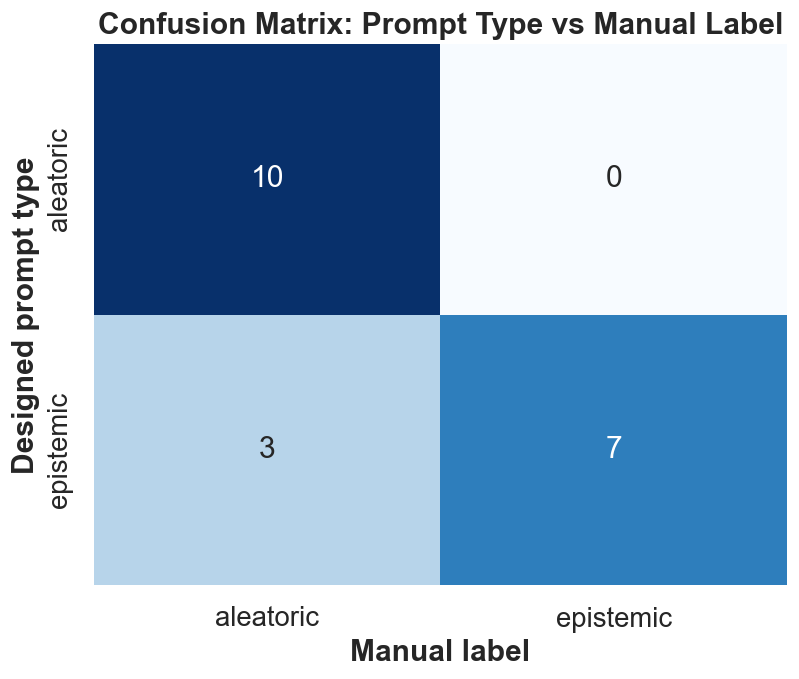

Manual label,aleatoric,epistemic
Designed prompt type,,
aleatoric,10,0
epistemic,3,7


In [8]:
agreement_rate = labelled_df["agreement"].mean()
display(Markdown(f"**Agreement rate:** {agreement_rate:.2%}"))

confusion = pd.crosstab(
    labelled_df["prompt_type"],
    labelled_df["manual_label"],
    rownames=["Designed prompt type"],
    colnames=["Manual label"],
    dropna=False,
)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Confusion Matrix: Prompt Type vs Manual Label")
save_and_show(fig, "phase1_confusion_matrix.png")

display(confusion)


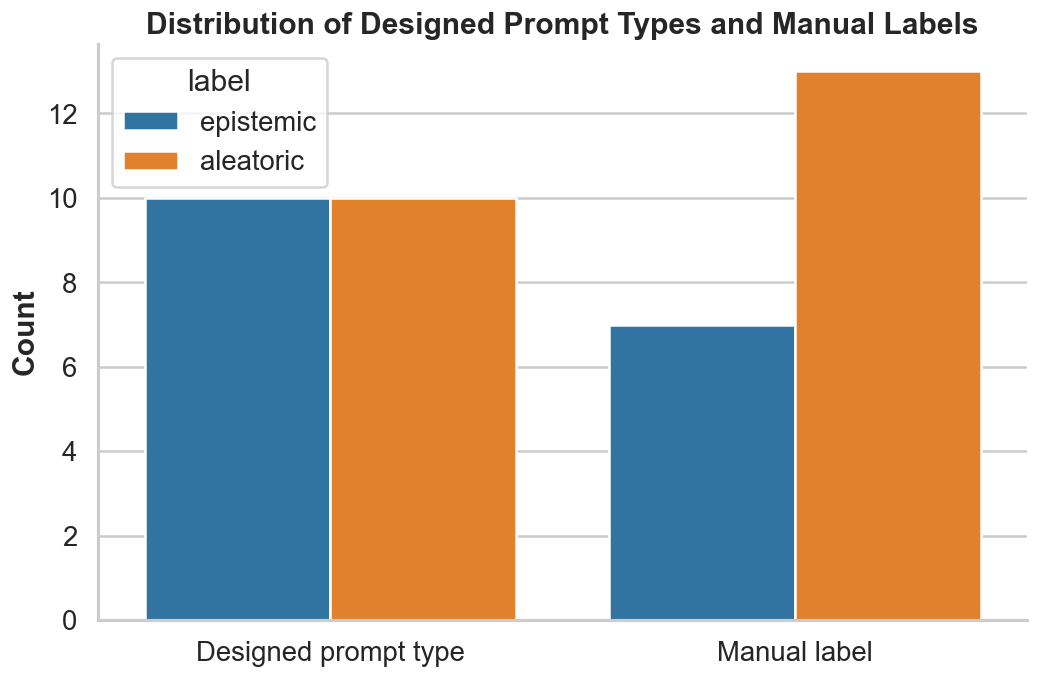

In [9]:
distribution_df = labelled_df.melt(
    id_vars=["prompt_id"],
    value_vars=["prompt_type", "manual_label"],
    var_name="source",
    value_name="label",
)
distribution_df["source"] = distribution_df["source"].replace({
    "prompt_type": "Designed prompt type",
    "manual_label": "Manual label",
})

fig, ax = plt.subplots(figsize=(9, 6))
sns.countplot(data=distribution_df, x="source", hue="label", palette=PALETTE, ax=ax)
ax.set_title("Distribution of Designed Prompt Types and Manual Labels")
ax.set_xlabel("")
ax.set_ylabel("Count")
save_and_show(fig, "phase1_grouped_bar_labels_vs_types.png")


In [10]:
disagreements_df = labelled_df.loc[~labelled_df["agreement"], [
    "prompt_id",
    "prompt_text",
    "prompt_type",
    "generated_cq",
    "manual_label",
]].copy()

display(Markdown("**Disagreement cases**"))
if disagreements_df.empty:
    print("No disagreement cases found.")
else:
    pd.set_option("display.max_colwidth", None)
    display(disagreements_df)


**Disagreement cases**

,prompt_id,prompt_text,prompt_type,generated_cq,manual_label
3,4,Summarise the key arguments in Harlow Pendleton's theory of asymmetric cognition.,epistemic,What aspects of Harlow Pendleton’s theory are you most interested in understanding?,aleatoric
5,6,How does the Mossfield protocol differ from standard TCP handshake procedures?,epistemic,What aspects of the Mossfield protocol are you most interested in comparing to TCP handshakes?,aleatoric
8,9,What is the population of Quelimares city in northern Brazil?,epistemic,What is the current year you are asking about?,aleatoric


C:\Users\dagxx\AppData\Local\Temp\ipykernel_17104\812469514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=labelled_df, x="manual_label", y="cq_word_count", palette=PALETTE, ax=ax)


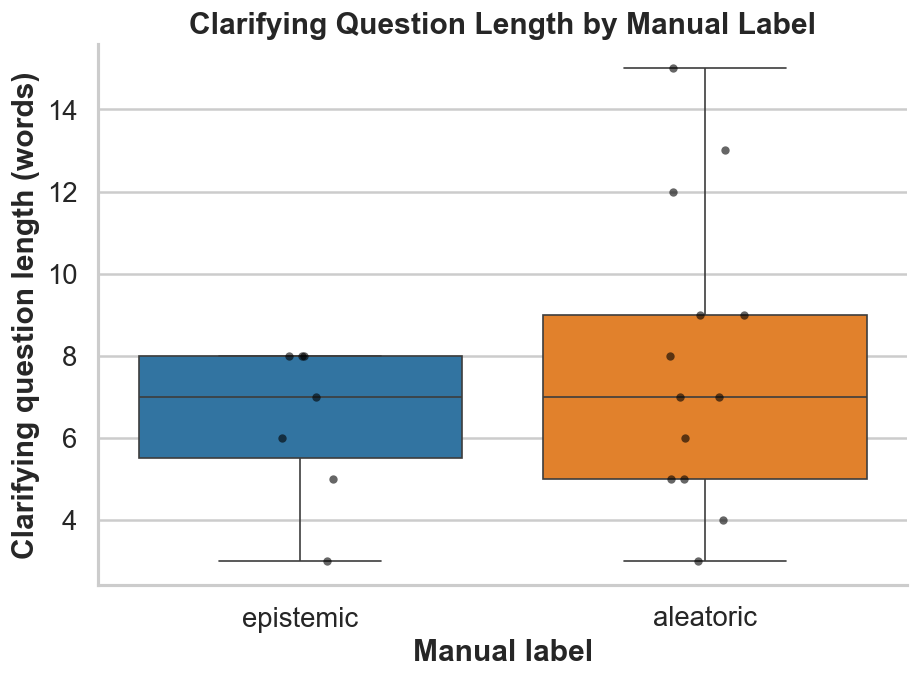

,count,mean,std,min,25%,50%,75%,max
manual_label,,,,,,,,
aleatoric,13.0,7.923077,3.616203,3.0,5.0,7.0,9.0,15.0
epistemic,7.0,6.428571,1.902379,3.0,5.5,7.0,8.0,8.0


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=labelled_df, x="manual_label", y="cq_word_count", palette=PALETTE, ax=ax)
sns.stripplot(data=labelled_df, x="manual_label", y="cq_word_count", color="black", alpha=0.6, ax=ax)
ax.set_title("Clarifying Question Length by Manual Label")
ax.set_xlabel("Manual label")
ax.set_ylabel("Clarifying question length (words)")
save_and_show(fig, "phase1_cq_length_boxplot.png")

display(labelled_df.groupby("manual_label")["cq_word_count"].describe())


# Phase 2 — Uncertainty Quantification

In [12]:
# Set REGENERATE_PHASE2 to True when you want to rebuild outputs/variation_runs.csv from scratch.
REGENERATE_PHASE2 = False
N_VARIATION_RUNS = 5

if VARIATION_RUNS_PATH.exists() and not REGENERATE_PHASE2:
    variation_runs_df = pd.read_csv(VARIATION_RUNS_PATH)
    if "generated_cq" not in variation_runs_df.columns:
        variation_runs_df["generated_cq"] = ""
    variation_runs_df["prompt_id"] = variation_runs_df["prompt_id"].astype(str).map(clean_text)
    variation_runs_df["generated_cq"] = variation_runs_df["generated_cq"].fillna("").astype(str).map(clean_text)
    variation_records = variation_runs_df.to_dict("records")
else:
    variation_records = []

completed_pairs = {
    (str(record["prompt_id"]), int(record["run_index"]))
    for record in variation_records
    if clean_text(record.get("generated_cq", ""))
}

total_jobs = len(prompts_df) * N_VARIATION_RUNS
completed_jobs = len(completed_pairs)

for row in prompts_df.itertuples(index=False):
    for run_index in range(1, N_VARIATION_RUNS + 1):
        key = (str(row.prompt_id), run_index)
        if key in completed_pairs and not REGENERATE_PHASE2:
            print(f"Reused existing Phase 2 result for prompt_id={row.prompt_id}, run={run_index}")
            continue

        generated_cq = call_gemini_for_cq(row.prompt_text, generation_config=PHASE2_GENERATION_CONFIG)
        variation_records.append({
            "prompt_id": row.prompt_id,
            "run_index": run_index,
            "generated_cq": generated_cq,
        })
        completed_pairs.add(key)
        completed_jobs += 1

        variation_runs_df = pd.DataFrame(variation_records)
        variation_runs_df = variation_runs_df.sort_values(["prompt_id", "run_index"]).drop_duplicates(
            subset=["prompt_id", "run_index"], keep="last"
        )
        variation_runs_df.to_csv(VARIATION_RUNS_PATH, index=False)
        print(f"Generated {completed_jobs}/{total_jobs} Phase 2 runs and checkpointed to {VARIATION_RUNS_PATH.name}")

        if completed_jobs < total_jobs:
            time.sleep(REQUEST_INTERVAL_SECONDS + random.uniform(0.5, 2.0))

variation_runs_df = pd.DataFrame(variation_records)
variation_runs_df = variation_runs_df.sort_values(["prompt_id", "run_index"]).drop_duplicates(
    subset=["prompt_id", "run_index"], keep="last"
)
variation_runs_df.to_csv(VARIATION_RUNS_PATH, index=False)

print(f"Saved variation runs to {VARIATION_RUNS_PATH}")
display(variation_runs_df.head(10))


Reused existing Phase 2 result for prompt_id=1, run=1
Reused existing Phase 2 result for prompt_id=1, run=2
Reused existing Phase 2 result for prompt_id=1, run=3
Reused existing Phase 2 result for prompt_id=1, run=4
Reused existing Phase 2 result for prompt_id=1, run=5
Reused existing Phase 2 result for prompt_id=2, run=1
Reused existing Phase 2 result for prompt_id=2, run=2
Reused existing Phase 2 result for prompt_id=2, run=3
Reused existing Phase 2 result for prompt_id=2, run=4
Reused existing Phase 2 result for prompt_id=2, run=5
Reused existing Phase 2 result for prompt_id=3, run=1
Reused existing Phase 2 result for prompt_id=3, run=2
Reused existing Phase 2 result for prompt_id=3, run=3
Reused existing Phase 2 result for prompt_id=3, run=4
Reused existing Phase 2 result for prompt_id=3, run=5
Reused existing Phase 2 result for prompt_id=4, run=1
Reused existing Phase 2 result for prompt_id=4, run=2
Reused existing Phase 2 result for prompt_id=4, run=3
Reused existing Phase 2 resu

,prompt_id,run_index,generated_cq
0,1,1,What industry does Kordemia operate in?
1,1,2,What industry does Kordemia operate in?
2,1,3,What industry does Kordemia operate in?
3,1,4,What industry does Kordemia operate in?
4,1,5,What industry does Kordemia operate in?
45,10,1,What beta blockers are you referring to?
46,10,2,What beta blockers are you referring to?
47,10,3,What beta blockers are you referring to?
48,10,4,What beta blockers are you referring to?
49,10,5,What beta blockers are you referring to?


In [13]:
variation_runs_df = pd.read_csv(VARIATION_RUNS_PATH)
variation_runs_df["prompt_id"] = variation_runs_df["prompt_id"].astype(str).map(clean_text)
variation_runs_df["generated_cq"] = variation_runs_df["generated_cq"].fillna("").astype(str)

pair_rows = []
for prompt_id, group in variation_runs_df.groupby("prompt_id", sort=True):
    run_records = group.sort_values("run_index").to_dict("records")
    if len(run_records) != N_VARIATION_RUNS:
        raise ValueError(f"Prompt {prompt_id} has {len(run_records)} runs; expected {N_VARIATION_RUNS}.")

    for left, right in itertools.combinations(run_records, 2):
        pair_rows.append({
            "prompt_id": prompt_id,
            "run_a": left["run_index"],
            "run_b": right["run_index"],
            "text_a": left["generated_cq"],
            "text_b": right["generated_cq"],
        })

pairwise_df = pd.DataFrame(pair_rows)

P, R, F1 = bertscore_score(
    pairwise_df["text_a"].tolist(),
    pairwise_df["text_b"].tolist(),
    lang="en",
    verbose=False,
)
pairwise_df["bertscore_f1"] = F1.detach().cpu().numpy()
pairwise_df["rougeL_f1"] = [
    rouge_l_f1(a, b)
    for a, b in zip(pairwise_df["text_a"], pairwise_df["text_b"])
]

variation_scores_df = (
    pairwise_df.groupby("prompt_id", as_index=False)
    .agg(mean_bertscore=("bertscore_f1", "mean"), mean_rougeL=("rougeL_f1", "mean"))
)
variation_scores_df["mean_bertscore"] = variation_scores_df["mean_bertscore"].clip(lower=0.0, upper=1.0)
variation_scores_df["mean_rougeL"] = variation_scores_df["mean_rougeL"].clip(lower=0.0, upper=1.0)
variation_scores_df["variation_score"] = (1 - variation_scores_df["mean_bertscore"]).clip(lower=0.0, upper=1.0)
variation_scores_df.to_csv(VARIATION_SCORES_PATH, index=False)

print(f"Saved variation scores to {VARIATION_SCORES_PATH}")
display(variation_scores_df)


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

Loading weights:  70%|██████▉   | 271/389 [00:00<00:00, 2708.31it/s]

Loading weights: 100%|██████████| 389/389 [00:00<00:00, 3006.96it/s]


RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Saved variation scores to D:\final_project\pilot_study\outputs\variation_scores.csv


,prompt_id,mean_bertscore,mean_rougeL,variation_score
0,1,1.000000,1.000,0.000000e+00
1,10,1.000000,1.000,1.192093e-07
2,11,1.000000,1.000,0.000000e+00
3,12,1.000000,1.000,0.000000e+00
4,13,1.000000,1.000,1.192093e-07
5,14,1.000000,1.000,0.000000e+00
6,15,1.000000,1.000,0.000000e+00
7,16,1.000000,1.000,0.000000e+00
8,17,1.000000,1.000,0.000000e+00
9,18,1.000000,1.000,1.788139e-07


## Phase 2 Analysis

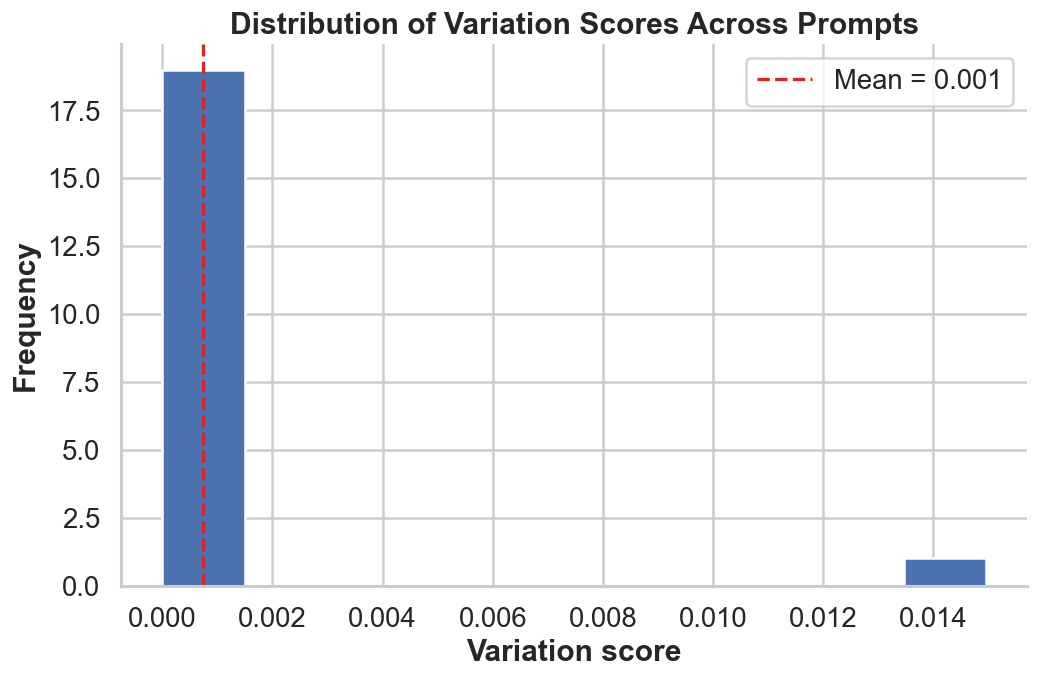

In [14]:
variation_scores_df = pd.read_csv(VARIATION_SCORES_PATH)
variation_scores_df["prompt_id"] = variation_scores_df["prompt_id"].astype(str).map(clean_text)
variation_enriched_df = prompts_df.merge(variation_scores_df, on="prompt_id", how="inner")
variation_with_labels_df = variation_enriched_df.merge(
    labelled_df[["prompt_id", "manual_label"]], on="prompt_id", how="left"
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(variation_enriched_df["variation_score"], bins=10, color="#4c72b0", edgecolor="white")
mean_variation = variation_enriched_df["variation_score"].mean()
ax.axvline(mean_variation, color="#d62728", linestyle="--", linewidth=2, label=f"Mean = {mean_variation:.3f}")
ax.set_title("Distribution of Variation Scores Across Prompts")
ax.set_xlabel("Variation score")
ax.set_ylabel("Frequency")
ax.legend()
save_and_show(fig, "phase2_variation_histogram.png")


C:\Users\dagxx\AppData\Local\Temp\ipykernel_17104\3341628917.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=variation_with_labels_df, x="prompt_type", y="variation_score", palette=PALETTE, ax=axes[0])
C:\Users\dagxx\AppData\Local\Temp\ipykernel_17104\3341628917.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=variation_with_labels_df, x="manual_label", y="variation_score", palette=PALETTE, ax=axes[1])


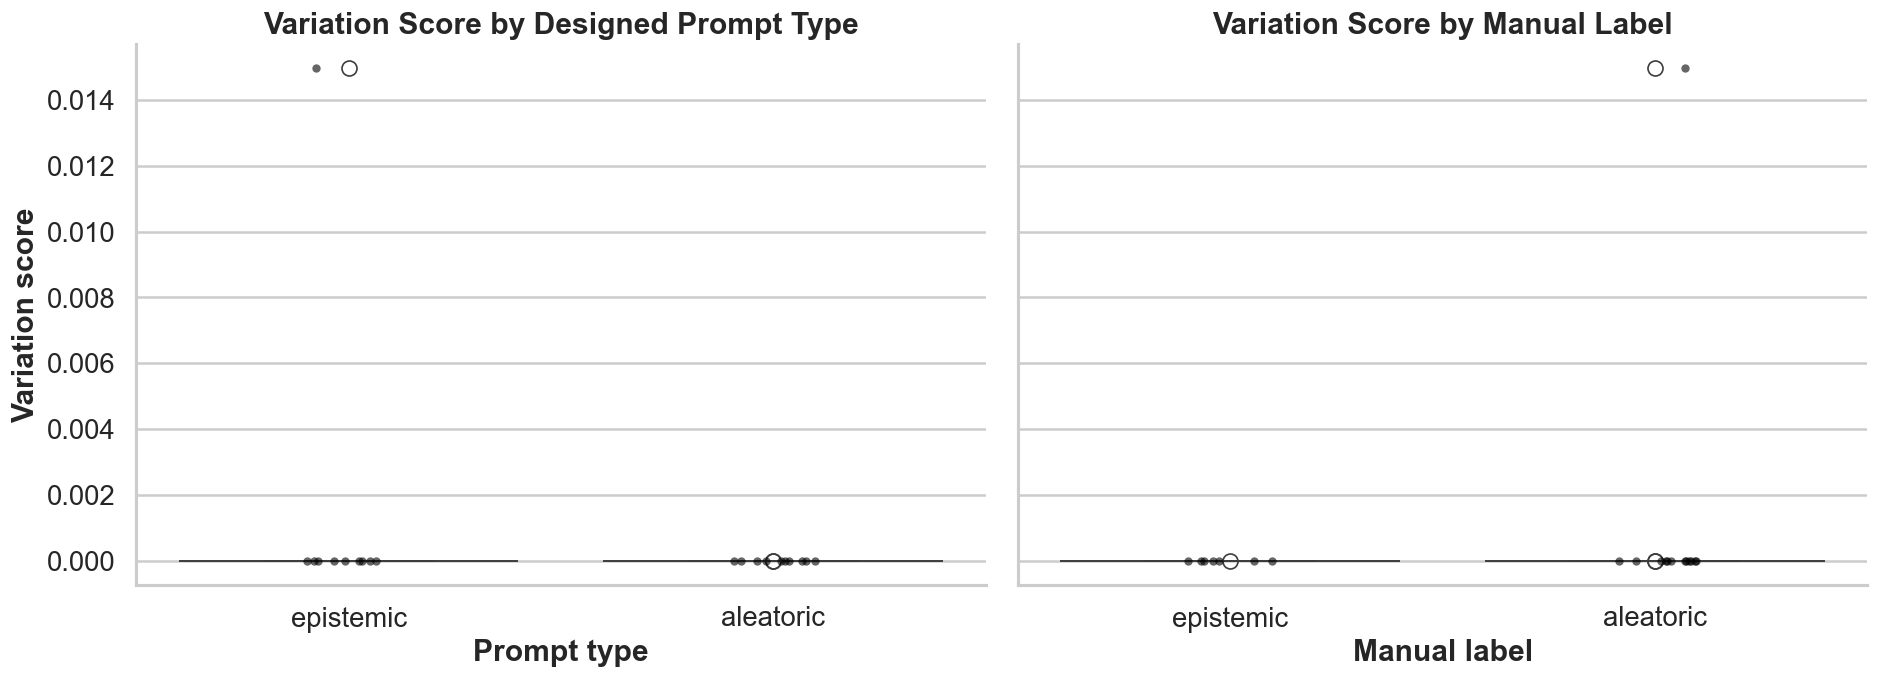

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

sns.boxplot(data=variation_with_labels_df, x="prompt_type", y="variation_score", palette=PALETTE, ax=axes[0])
sns.stripplot(data=variation_with_labels_df, x="prompt_type", y="variation_score", color="black", alpha=0.6, ax=axes[0])
axes[0].set_title("Variation Score by Designed Prompt Type")
axes[0].set_xlabel("Prompt type")
axes[0].set_ylabel("Variation score")

sns.boxplot(data=variation_with_labels_df, x="manual_label", y="variation_score", palette=PALETTE, ax=axes[1])
sns.stripplot(data=variation_with_labels_df, x="manual_label", y="variation_score", color="black", alpha=0.6, ax=axes[1])
axes[1].set_title("Variation Score by Manual Label")
axes[1].set_xlabel("Manual label")
axes[1].set_ylabel("Variation score")

save_and_show(fig, "phase2_variation_boxplots.png")


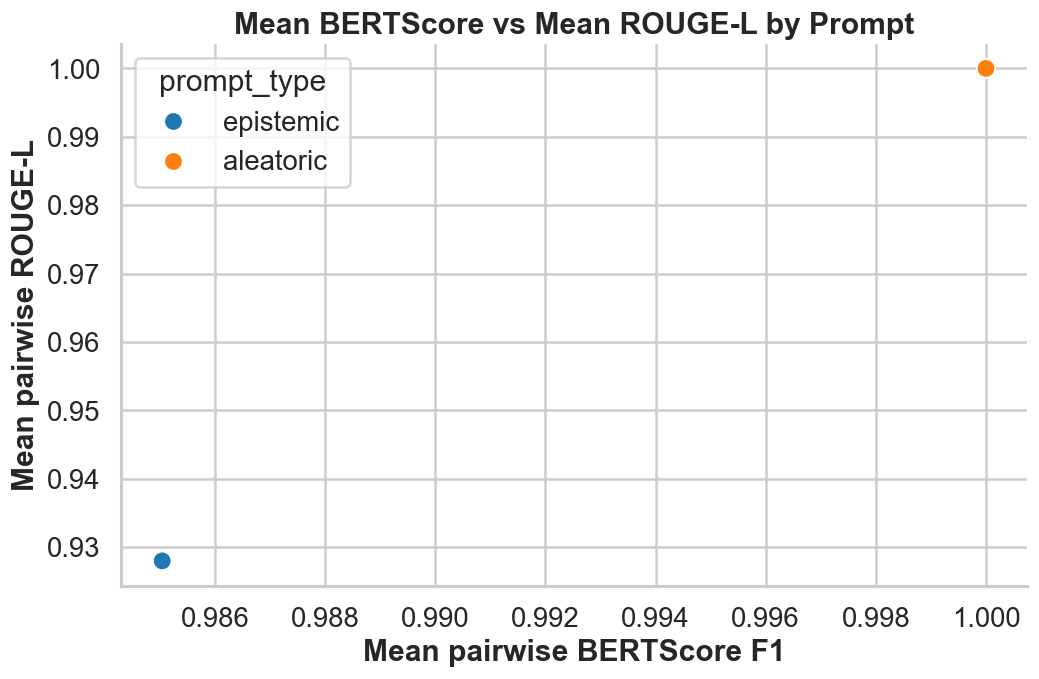

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=variation_enriched_df,
    x="mean_bertscore",
    y="mean_rougeL",
    hue="prompt_type",
    palette=PALETTE,
    s=120,
    ax=ax,
)
ax.set_title("Mean BERTScore vs Mean ROUGE-L by Prompt")
ax.set_xlabel("Mean pairwise BERTScore F1")
ax.set_ylabel("Mean pairwise ROUGE-L")
save_and_show(fig, "phase2_bertscore_vs_rougel_scatter.png")


In [17]:
variation_reading_df = variation_enriched_df.merge(
    labelled_df[["prompt_id", "generated_cq"]], on="prompt_id", how="left"
)

top_high = variation_reading_df.sort_values("variation_score", ascending=False).head(5)
top_low = variation_reading_df.sort_values("variation_score", ascending=True).head(5)
reading_columns = [col for col in ["prompt_id", "prompt_text", "prompt_type", "variety", "variation_score", "generated_cq"] if col in variation_reading_df.columns]

display(Markdown("**Top 5 highest-variation prompts**"))
display(top_high[reading_columns])

display(Markdown("**Top 5 lowest-variation prompts**"))
display(top_low[reading_columns])


**Top 5 highest-variation prompts**

,prompt_id,prompt_text,prompt_type,variety,variation_score,generated_cq
3,4,Summarise the key arguments in Harlow Pendleton's theory of asymmetric cognition.,epistemic,fabricated academic work,1.495630e-02,What aspects of Harlow Pendleton’s theory are you most interested in understanding?
1,2,Explain the Verlinden compression theorem and its applications.,epistemic,fabricated concept,1.788139e-07,What is the context of the theorem's application?
17,18,What is the fastest route from here to the nearest hospital?,aleatoric,missing spatial context,1.788139e-07,Where are you currently located?
9,10,Describe the side effects of Veratinol when combined with beta blockers.,epistemic,fabricated drug name,1.192093e-07,What beta blockers are you referring to?
12,13,Recommend a good book for me to read this weekend.,aleatoric,missing personal preference context,1.192093e-07,What genres do you typically enjoy reading?


**Top 5 lowest-variation prompts**

,prompt_id,prompt_text,prompt_type,variety,variation_score,generated_cq
0,1,What are the main export products of Kordemia?,epistemic,fabricated entity,0.0,What industry does Kordemia operate in?
2,3,What programming language is the Drexel-9 microprocessor optimised for?,epistemic,fabricated technical entity,0.0,What is the Drexel-9 microprocessor?
5,6,How does the Mossfield protocol differ from standard TCP handshake procedures?,epistemic,fabricated technical protocol,0.0,What aspects of the Mossfield protocol are you most interested in comparing to TCP handshakes?
4,5,What were the outcomes of the 2019 Tarethia climate accords?,epistemic,fabricated event,0.0,What is Tarethia?
6,7,What is the boiling point of flerovium under standard atmospheric pressure?,epistemic,real but obscure entity with unknown properties,0.0,What standard atmospheric pressure are you referring to?


# Phase 3 — Correlation and Integration

In [18]:
final_df = labelled_df.merge(variation_scores_df, on="prompt_id", how="inner")
final_df["agreement"] = final_df["manual_label"] == final_df["prompt_type"]
final_df["manual_label_binary"] = final_df["manual_label"].map({"aleatoric": 0, "epistemic": 1})
final_df["agreement_label"] = final_df["agreement"].map({True: "Agreement", False: "Disagreement"})

corr_result = pointbiserialr(final_df["manual_label_binary"], final_df["variation_score"])
display(Markdown(
    f"**Point-biserial correlation** between `variation_score` and `manual_label` (0 = aleatoric, 1 = epistemic): "
    f"r = {corr_result.statistic:.3f}, p = {corr_result.pvalue:.4f}"
))


**Point-biserial correlation** between `variation_score` and `manual_label` (0 = aleatoric, 1 = epistemic): r = -0.168, p = 0.4780

In [19]:
interpretation_direction = "higher" if corr_result.statistic > 0 else "lower"
interpretation_strength = abs(corr_result.statistic)

display(Markdown(
    "### Plain-language interpretation\n"
    f"The correlation estimates whether prompts manually labelled as **epistemic** tend to have {interpretation_direction} variation scores than prompts manually labelled as **aleatoric**. "
    f"Here, the observed correlation is **r = {corr_result.statistic:.3f}** with **p = {corr_result.pvalue:.4f}**. "
    f"A value closer to zero suggests a weak relationship; larger absolute values suggest a stronger relationship."
))


### Plain-language interpretation
The correlation estimates whether prompts manually labelled as **epistemic** tend to have lower variation scores than prompts manually labelled as **aleatoric**. Here, the observed correlation is **r = -0.168** with **p = 0.4780**. A value closer to zero suggests a weak relationship; larger absolute values suggest a stronger relationship.

In [20]:
def run_mannwhitney(df: pd.DataFrame, label_column: str) -> dict:
    epistemic_scores = df.loc[df[label_column] == "epistemic", "variation_score"]
    aleatoric_scores = df.loc[df[label_column] == "aleatoric", "variation_score"]
    result = mannwhitneyu(epistemic_scores, aleatoric_scores, alternative="two-sided")
    return {
        "grouping": label_column,
        "u_statistic": result.statistic,
        "p_value": result.pvalue,
        "n_epistemic": len(epistemic_scores),
        "n_aleatoric": len(aleatoric_scores),
    }


mannwhitney_results_df = pd.DataFrame([
    run_mannwhitney(final_df, "prompt_type"),
    run_mannwhitney(final_df, "manual_label"),
])

display(Markdown("**Mann-Whitney U test results**"))
display(mannwhitney_results_df)


**Mann-Whitney U test results**

,grouping,u_statistic,p_value,n_epistemic,n_aleatoric
0,prompt_type,56.0,0.584291,10,10
1,manual_label,47.0,0.916946,7,13


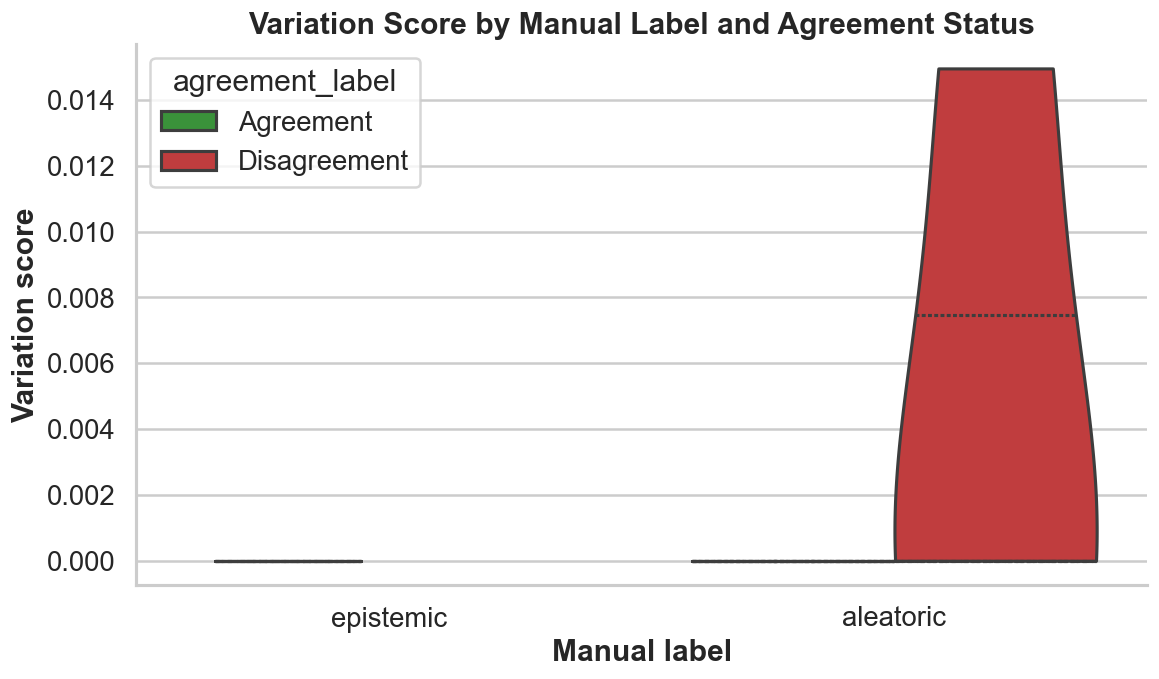

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=final_df,
    x="manual_label",
    y="variation_score",
    hue="agreement_label",
    palette=PALETTE,
    cut=0,
    inner="quartile",
    ax=ax,
)
ax.set_title("Variation Score by Manual Label and Agreement Status")
ax.set_xlabel("Manual label")
ax.set_ylabel("Variation score")
save_and_show(fig, "phase3_violin_manual_label_agreement.png")


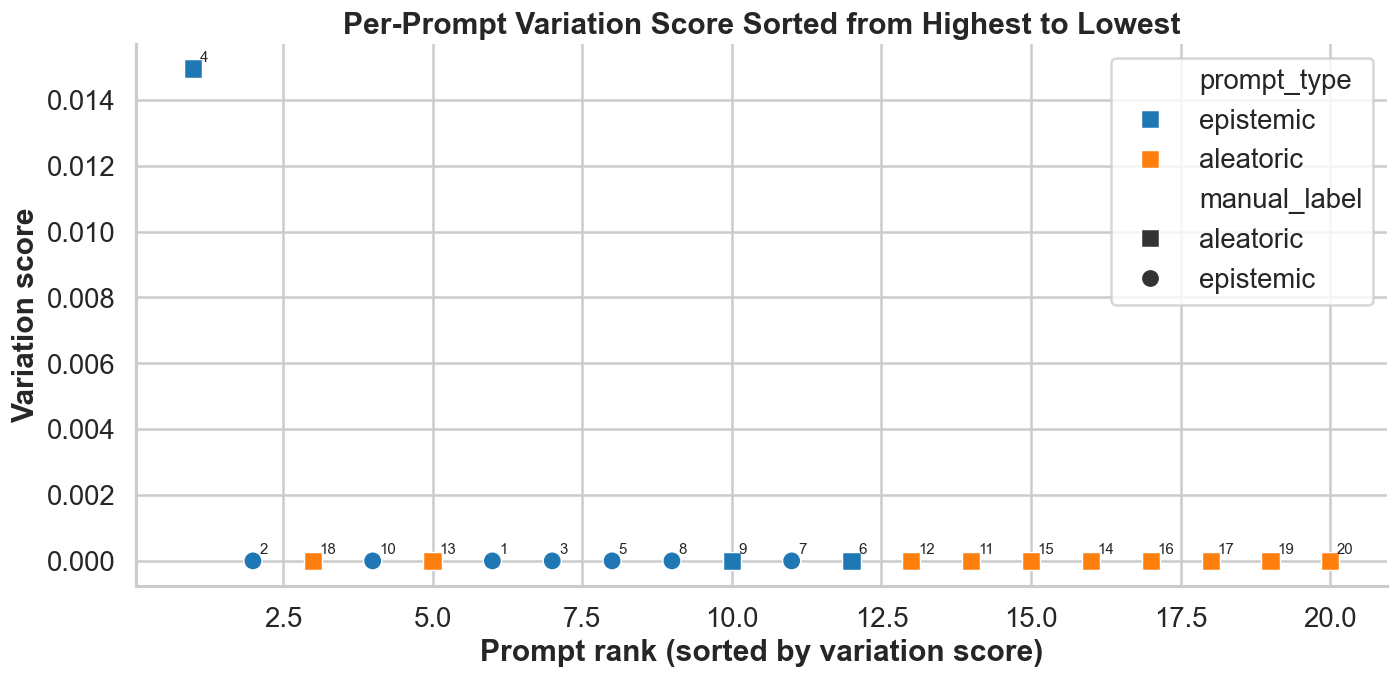

In [22]:
sorted_final_df = final_df.sort_values("variation_score", ascending=False).reset_index(drop=True).copy()
sorted_final_df["variation_rank"] = np.arange(1, len(sorted_final_df) + 1)

marker_map = {"epistemic": "o", "aleatoric": "s"}

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(
    data=sorted_final_df,
    x="variation_rank",
    y="variation_score",
    hue="prompt_type",
    style="manual_label",
    palette=PALETTE,
    markers=marker_map,
    s=120,
    ax=ax,
)

ax.set_title("Per-Prompt Variation Score Sorted from Highest to Lowest")
ax.set_xlabel("Prompt rank (sorted by variation score)")
ax.set_ylabel("Variation score")

for row in sorted_final_df.itertuples(index=False):
    ax.annotate(row.prompt_id, (row.variation_rank, row.variation_score), textcoords="offset points", xytext=(4, 4), fontsize=9)

save_and_show(fig, "phase3_prompt_level_variation_scatter.png")


In [23]:
summary_columns = [
    col
    for col in ["prompt_id", "prompt_type", "variety", "manual_label", "agreement", "variation_score", "generated_cq"]
    if col in final_df.columns
]
summary_table = final_df[summary_columns].sort_values("variation_score", ascending=False)

display(Markdown("**Final summary table**"))
display(summary_table)


**Final summary table**

,prompt_id,prompt_type,variety,manual_label,agreement,variation_score,generated_cq
3,4,epistemic,fabricated academic work,aleatoric,False,1.495630e-02,What aspects of Harlow Pendleton’s theory are you most interested in understanding?
1,2,epistemic,fabricated concept,epistemic,True,1.788139e-07,What is the context of the theorem's application?
17,18,aleatoric,missing spatial context,aleatoric,True,1.788139e-07,Where are you currently located?
9,10,epistemic,fabricated drug name,epistemic,True,1.192093e-07,What beta blockers are you referring to?
12,13,aleatoric,missing personal preference context,aleatoric,True,1.192093e-07,What genres do you typically enjoy reading?
0,1,epistemic,fabricated entity,epistemic,True,0.000000e+00,What industry does Kordemia operate in?
2,3,epistemic,fabricated technical entity,epistemic,True,0.000000e+00,What is the Drexel-9 microprocessor?
4,5,epistemic,fabricated event,epistemic,True,0.000000e+00,What is Tarethia?
7,8,epistemic,future event outside training data,epistemic,True,0.000000e+00,What country hosted the 2031 FIFA World Cup?
8,9,epistemic,plausible but fabricated place,aleatoric,False,0.000000e+00,What is the current year you are asking about?


## Reflection Template

Use the prompts below to record your qualitative interpretation after reviewing the outputs.

### Did the labels feel natural to assign?

_Your notes here._

### Which cases were hardest to classify and why?

_Your notes here._

### Did epistemic and aleatoric prompts vary differently as hypothesised?

_Your notes here._

### What does the correlation result suggest about the core research idea?

_Your notes here._

### Go or no-go for the full benchmark?

_Your notes here._
